<a href="https://colab.research.google.com/github/acnoori/CE5331/blob/main/RnD_Competition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Game Theory: Competition in Research and Development (R&D)

This educational notebook explores the dynamics of strategic competition between two startups investing in Research and Development.

### Scenario Overview
Two startups, **Firm 1** and **Firm 2**, compete for leadership in a software market.
* The leader wins (revenue = 1) and the follower loses (revenue = 0).
* Each firm $i$ can invest $s_i \in [0.001, 1]$ units into R&D at a cost of $s_i / 4$.
* If Firm 1 invests $x$ units and Firm 2 invests $y$ units, the probability of Firm 1 winning is $\frac{x}{x + y}$.

Thus, the payoff functions are:
* **Firm 1 Payoff:** $\Pi_1(x, y) = \frac{x}{x+y} - \frac{x}{4}$
* **Firm 2 Payoff:** $\Pi_2(x, y) = \frac{y}{x+y} - \frac{y}{4}$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define the Payoff Functions
def payoff_firm1(x, y):
    return x / (x + y) - x / 4.0

def payoff_firm2(x, y):
    return y / (x + y) - y / 4.0

# Define Best Response Functions derived analytically:
# BR_1(y) = 2*sqrt(y) - y
# BR_2(x) = 2*sqrt(x) - x
def best_response_1(y):
    return 2 * np.sqrt(y) - y

def best_response_2(x):
    return 2 * np.sqrt(x) - x

## 1. Visualizing the Best Response and Nash Equilibrium

By taking the first-order conditions of the payoff functions, we get the best response curves:
$$x^*(y) = 2\sqrt{y} - y$$
$$y^*(x) = 2\sqrt{x} - x$$

Let's plot these curves to find their intersection point, which represents the **Nash Equilibrium**.

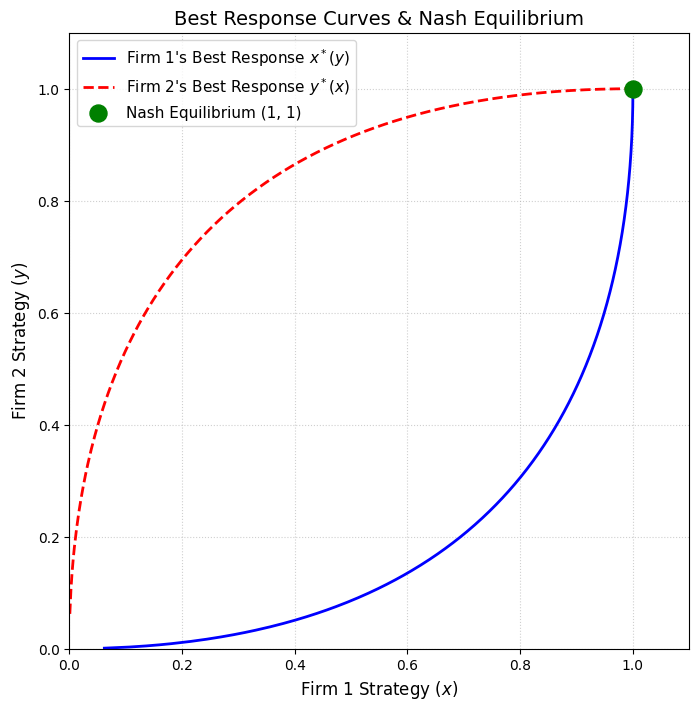

In [2]:
grid = np.linspace(0.001, 1, 500)

br1_vals = best_response_1(grid)  # x values as a function of y
br2_vals = best_response_2(grid)  # y values as a function of x

plt.figure(figsize=(8, 8))
plt.plot(br1_vals, grid, label="Firm 1's Best Response $x^*(y)$", color='blue', linewidth=2)
plt.plot(grid, br2_vals, label="Firm 2's Best Response $y^*(x)$", color='red', linewidth=2, linestyle='--')
plt.scatter([1.0], [1.0], color='green', s=150, zorder=5, label='Nash Equilibrium (1, 1)')

plt.xlim(0, 1.1)
plt.ylim(0, 1.1)
plt.xlabel("Firm 1 Strategy ($x$)", fontsize=12)
plt.ylabel("Firm 2 Strategy ($y$)", fontsize=12)
plt.title("Best Response Curves & Nash Equilibrium", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## 2. Iterative Elimination & Rationalizability
Starting from the lowest possible strategy $x_0 = y_0 = 0.001$, any strategy below $x^*(y_0)$ is strictly dominated and can be eliminated. If we recursively apply this logic:

$$x_n = 2\sqrt{x_{n-1}} - x_{n-1}$$

Let's simulate this convergence process numerically to see how many iterations are required to reach near-unity.

In [3]:
iterations = 15
strategy_history = [0.001] # starting point x_0

for i in range(1, iterations):
    next_strategy = best_response_1(strategy_history[-1])
    strategy_history.append(next_strategy)

# Display the convergence steps
for step, val in enumerate(strategy_history):
    print(f"Iteration {step:2d}: Minimum Rationalizable Strategy = {val:.6f}")

Iteration  0: Minimum Rationalizable Strategy = 0.001000
Iteration  1: Minimum Rationalizable Strategy = 0.062246
Iteration  2: Minimum Rationalizable Strategy = 0.436736
Iteration  3: Minimum Rationalizable Strategy = 0.884984
Iteration  4: Minimum Rationalizable Strategy = 0.996488
Iteration  5: Minimum Rationalizable Strategy = 0.999997
Iteration  6: Minimum Rationalizable Strategy = 1.000000
Iteration  7: Minimum Rationalizable Strategy = 1.000000
Iteration  8: Minimum Rationalizable Strategy = 1.000000
Iteration  9: Minimum Rationalizable Strategy = 1.000000
Iteration 10: Minimum Rationalizable Strategy = 1.000000
Iteration 11: Minimum Rationalizable Strategy = 1.000000
Iteration 12: Minimum Rationalizable Strategy = 1.000000
Iteration 13: Minimum Rationalizable Strategy = 1.000000
Iteration 14: Minimum Rationalizable Strategy = 1.000000


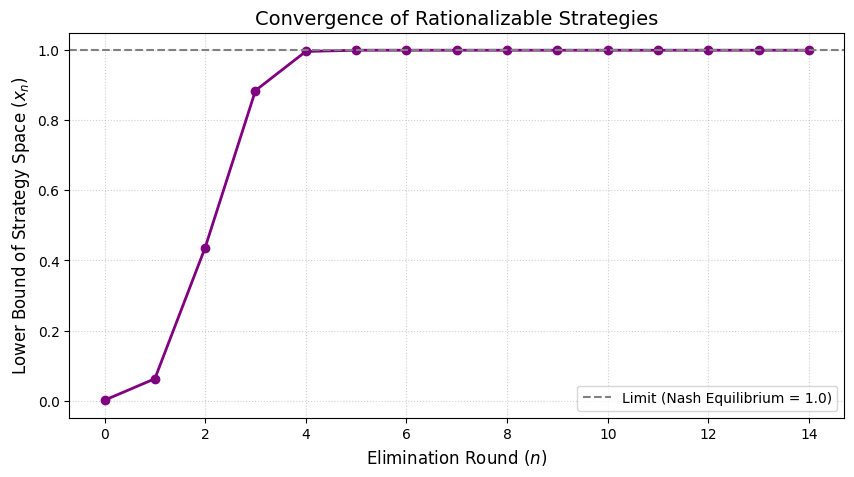

In [4]:
plt.figure(figsize=(10, 5))
plt.plot(range(iterations), strategy_history, marker='o', color='purple', linestyle='-', linewidth=2)
plt.axhline(1.0, color='gray', linestyle='--', label='Limit (Nash Equilibrium = 1.0)')
plt.xlabel("Elimination Round ($n$)", fontsize=12)
plt.ylabel("Lower Bound of Strategy Space ($x_n$)", fontsize=12)
plt.title("Convergence of Rationalizable Strategies", fontsize=14)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

---
### References & Acknowledgement
This simulator is based on the curriculum and exercises of **MIT OpenCourseWare (OCW)**:
* **Course:** Chapter 8: Further Applications (Competition in Research and Development)
* **Original Exercise:** Exercise 8.5 & 8.6 [Midterm 1, 2002]